# Stock Analysis

## Data Preprocessing

In [80]:
import pandas as pd
import numpy as np
import yfinance as yf
from sklearn.linear_model import LinearRegression

stock = 'RELIANCE.NS'
data = yf.download(
    stock,
    start="2023-01-01",
    end="2026-01-01",
    auto_adjust=True
)

data.reset_index(inplace=True)

print("Data downloaded successfully")


[*********************100%***********************]  1 of 1 completed

Data downloaded successfully


In [81]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import matplotlib.pyplot as plt

In [82]:
data['MA20'] = data['Close'].rolling(window=20).mean()
data['MA50'] = data['Close'].rolling(window=50).mean()

data['Daily Return'] = data['Close'].pct_change()
data.dropna(inplace=True)

volatility = data['Daily Return'].std() * np.sqrt(252)

print("Volatility:", volatility)

Volatility: 0.20039954796950674


## Data Modeling and Train Test Split


In [84]:
data["Days"] = np.arange(len(data))

data['Lag1'] = data['Close'].shift(1)
data['Lag2'] = data['Close'].shift(2)
data['Lag3'] = data['Close'].shift(3)
data['Lag4'] = data['Close'].shift(4)
data['Lag5'] = data['Close'].shift(5)

data.dropna(inplace=True)

X = data[['Lag1','Lag2','Lag3','Lag4','Lag5']]
y = data["Close"].values.ravel()
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

## Train Model

In [86]:
model = LinearRegression()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("\nModel Performance")

print("MAE :", round(mae, 2))

print("RMSE :", round(rmse, 2))

print("R2 Score :", round(r2, 4))


Model Performance
MAE : 10.93
RMSE : 14.66
R2 Score : 0.9551


## Actual vs predicted

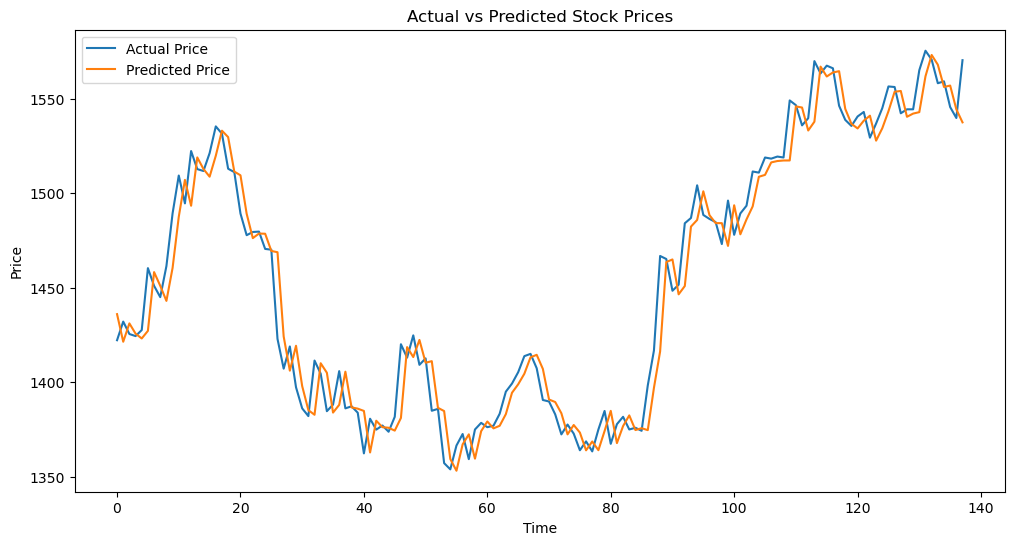

In [88]:
plt.figure(figsize=(12,6))
plt.plot(
    y_test,
    label="Actual Price"
)
plt.plot(
    y_pred,
    label="Predicted Price"
)
plt.title("Actual vs Predicted Stock Prices")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

## Volatility Chart

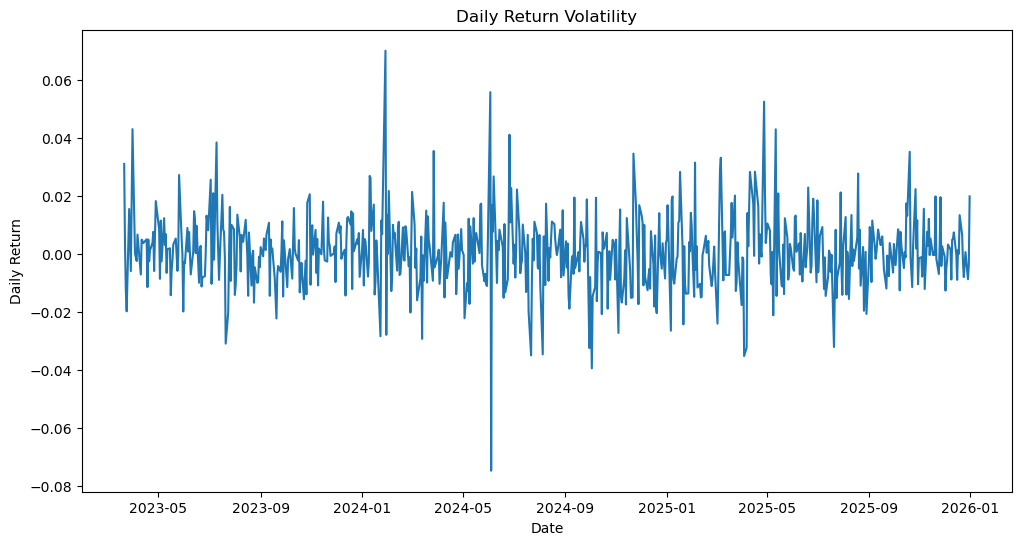

In [90]:
plt.figure(figsize=(12,6))
plt.plot(
    data["Date"],
    data["Daily Return"]
)
plt.title("Daily Return Volatility")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.show()

## Model Performance table

In [95]:
performance_df = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2 Score"],
    "Value": [mae, rmse, r2]
})
performance_df

,Metric,Value
0,MAE,10.926168
1,RMSE,14.658708
2,R2 Score,0.955058


In [97]:
## actual vs predicted
comparison_df = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})
comparison_df

,Actual Price,Predicted Price
0,1422.219849,1436.027058
1,1432.080444,1421.417351
2,1425.506592,1431.131273
3,1424.411011,1425.709502
4,1427.598389,1423.153842
...,...,...
133,1558.199951,1568.010049
134,1559.199951,1556.217883
135,1545.599976,1556.970751
136,1539.800049,1544.402016


## Export csv files

In [100]:
data.to_csv(
    "stock_data.csv",
    index=False
)

predicted_df.to_csv(
    "predicted_stock.csv",
    index=False
)

performance_df.to_csv(
    "model_metrics.csv",
    index=False
)

comparison_df.to_csv(
    "actual_vs_predicted.csv",
    index=False
)

print("\nCSV files generated successfully!")

print("\nFiles created:")
print("1. stock_data.csv")
print("2. predicted_stock.csv")
print("3. model_metrics.csv")
print("4. actual_vs_predicted.csv")


CSV files generated successfully!

Files created:
1. stock_data.csv
2. predicted_stock.csv
3. model_metrics.csv
4. actual_vs_predicted.csv
